In [ ]:
# https://scores.readthedocs.io/en/stable/tutorials/Fractions_Skill_Score.html

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from pathlib import Path
from datetime import datetime
import re
import pandas as pd

from dask.distributed import Client, wait
import os, sys
import psutil

sys.path.append('/home/548/cd3022/repos/Irradiance-comparisons/Irradiance-comparisons')
import logger
from read_datasets import read_dataset

LOG = logger.get_logger(__name__)

In [2]:
client = Client(
    n_workers=24,
    threads_per_worker=1
)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 24
Total threads: 24,Total memory: 95.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34659,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:35549,Total threads: 1
Dashboard: /proxy/46383/status,Memory: 3.96 GiB
Nanny: tcp://127.0.0.1:40827,


2025-10-22 19:46:04,683 - distributed.nanny.memory - WARNING - Worker tcp://127.0.0.1:38651 (pid=3884256) exceeded 95% memory budget. Restarting...
2025-10-22 19:46:04,758 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:38651' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('where-45834bebced2c6c3871d4d0fc2aea4d5', 91, 0, 0), ('where-45834bebced2c6c3871d4d0fc2aea4d5', 50, 0, 0), ('where-45834bebced2c6c3871d4d0fc2aea4d5', 137, 0, 0), ('where-45834bebced2c6c3871d4d0fc2aea4d5', 12, 0, 0), ('where-45834bebced2c6c3871d4d0fc2aea4d5', 109, 0, 0), ('where-45834bebced2c6c3871d4d0fc2aea4d5', 2, 0, 0), ('where-45834bebced2c6c3871d4d0fc2aea4d5', 41, 0, 0), ('where-45834bebced2c6c3871d4d0fc2aea4d5', 0, 0, 0), ('where-45834bebced2c6c3871d4d0fc2aea4d5', 25, 0, 0), ('where-45834bebced2c6c3871d4d0fc2aea4d5', 13, 0, 0), ('where-45834bebced2c6c3871d4d0fc2aea4d5', 71, 0, 0), ('where-45834bebced2c6c3871d4d0fc2aea4d5', 77, 0, 0), ('where-45834b

In [3]:
ancil = xr.open_dataset('/g/data/ra22/satellite-products/arc/obs/himawari-ahi/fldk/latest/ancillary/00000000000000-P1S-ABOM_GEOM_SENSOR-PRJ_GEOS141_2000-HIMAWARI8-AHI.nc')
ancil = ancil.isel(time=0)

In [4]:
ancil

<xarray.Dataset> Size: 605MB
Dimensions:                  (y: 5500, x: 5500)
Coordinates:
    time                     datetime64[ns] 8B 2020-02-22T06:00:00
  * x                        (x) float64 44kB -5.499e+06 ... 5.499e+06
  * y                        (y) float64 44kB 5.499e+06 5.497e+06 ... -5.499e+06
Data variables:
    geostationary            float32 4B ...
    invalid_navigation_mask  (y, x) float32 121MB ...
    lat                      (y, x) float32 121MB ...
    lon                      (y, x) float32 121MB ...
    scan_line_time           (y) datetime64[ns] 44kB ...
    sensor_azimuth_angle     (y, x) float32 121MB ...
    sensor_zenith_angle      (y, x) float32 121MB ...
Attributes: (12/60)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    acknowledgment:                  See disclaimer
    cdm_data_type:                   grid
    comment:                         AGLS sensor geometry product
    contributor_name:                Commonwealth of Australia, Bureau of Met...
    ...                              ...
    time_coverage_start:             20200222T060021Z
    wmo_platform_name:               Himawari-8
    wmo_satellite_number:            173
    history:                         Thu Jan 13 06:33:25 2022: ncatted -O -a ...
    NCO:                             netCDF Operators version 4.7.7 (Homepage...
    product_version:                 1.0

In [6]:
lat_min = -44.5
lat_max = -10.0
lon_min = 112.0
lon_max = 156.126

path = Path('/g/data/rv74/satellite-products/arc/der/himawari-ahi/cloud/cmic/latest/2020/01/01')
files = [f for f in path.glob('*.nc')]

def open_cmic(file):
    # open data file
    ds = xr.open_dataset(
        file,
        chunks='auto'
    )

    # time to be assigned
    match = re.search(r"_(\d{8}T\d{6})Z\.nc$", f.name)
    time=pd.to_datetime(match.group(1), format="%Y%m%dT%H%M%S")

    # assign lat/lon (time) coords using ancillary file
    ds = ds.assign_coords(
        time=time,
        lat=(("ny", "nx"), ancil.lat.data),
        lon=(("ny", "nx"), ancil.lon.data)
    )
    
    mask = (
        (ds.lat >= lat_min) & (ds.lat <= lat_max) &
        (ds.lon >= lon_min) & (ds.lon <= lon_max)
    )
    ds = ds.where(mask, drop=True)
    return ds


datasets = []
for f in (files):
    ds = open_cmic(f)
    datasets.append(ds)
ds = xr.concat(datasets, dim="time")

In [22]:
ds['cmic_lwp'] = xr.where(ds.cmic_lwp.isnull(), 0, ds.cmic_lwp)

In [31]:
ds = ds.where((ds.lon >= lon_min) & (ds.lon <= lon_max), drop=True)

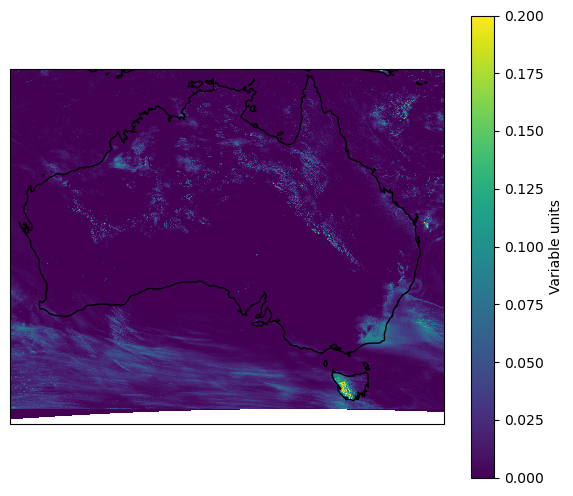

In [42]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()}, figsize=(7, 6))

pcm = ax.pcolormesh(
    ds.lon,
    ds.lat,
    ds.cmic_lwp.mean(dim='time'),
    cmap="viridis",
    transform=ccrs.PlateCarree(),
    vmin=0,
    vmax=0.2
)

ax.coastlines()
plt.xlim(112, 156)
plt.ylim(-46, -10)
plt.colorbar(pcm, ax=ax, label="Variable units")
plt.show()

In [47]:
import xesmf as xe

# Define target 1D grid
target = xr.Dataset({
    "lat": (["lat"], np.linspace(lat_min, lat_max, bar.lat.shape[0])),
    "lon": (["lon"], np.linspace(lon_min, lon_max, bar.lon.shape[0])),
})

regridder = xe.Regridder(ds, target, "bilinear")
ds_reg = regridder(ds)

In [9]:
def get_barra(var):
    BARRA = Path('/g/data/ob53/BARRA2/output/reanalysis/')
    BARRA_R2 = BARRA / "AUS-11/BOM/ERA5/historical/hres/BARRA-R2/v1"
    BARRA_R2_DIR = BARRA_R2 / "1hr"
    
    files = sorted([f for f in BARRA_R2_DIR.glob(f'{var}/latest/*1hr_20*.nc')])
    
    def _preprocess(ds):
        return ds.sel(lat=slice(-44.5, -10), lon=slice(112, 156.26))
    barra_r2 = xr.open_mfdataset(
        files,
        chunks={'time':24, 'lat':256, 'lon':256},
        concat_dim='time',
        combine='nested',
        data_vars='minimal',
        coords='minimal',
        compat='override',
        parallel=True,
        preprocess=_preprocess
    )
    return barra_r2

def get_himawari(year):
    # get Himawari data
    himawari_list = []
    for month in range (1, 2):
        date = f'{year}-{month:02d}' 
        himawari = read_dataset(
                dataset='himawari',
                resolution='hourly',
                date=date
            )
        himawari_list.append(himawari)
    him_ds = xr.concat(himawari_list, dim='time', data_vars='minimal')
    return him_ds

In [10]:
bar = get_barra('clwvi')

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.06/lib/python3.11/site-packages/dask/_task_spec.py:763: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 24. This could degrade performance. Instead, consider rechunking after loading.
  return self.func(*new_argspec, **kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.06/lib/python3.11/site-packages/dask/_task_spec.py:763: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 256. This could degrade performance. Instead, consider rechunking after loading.
  return self.func(*new_argspec, **kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.06/lib/python3.11/site-packages/dask/_task_spec.py:763: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 256. This could degrade performance. Instead, consider rechunking after loading.
  return self.func(*new_argspec, **kwargs

In [15]:
bar = bar.sel(time=ds.time, method='nearest')

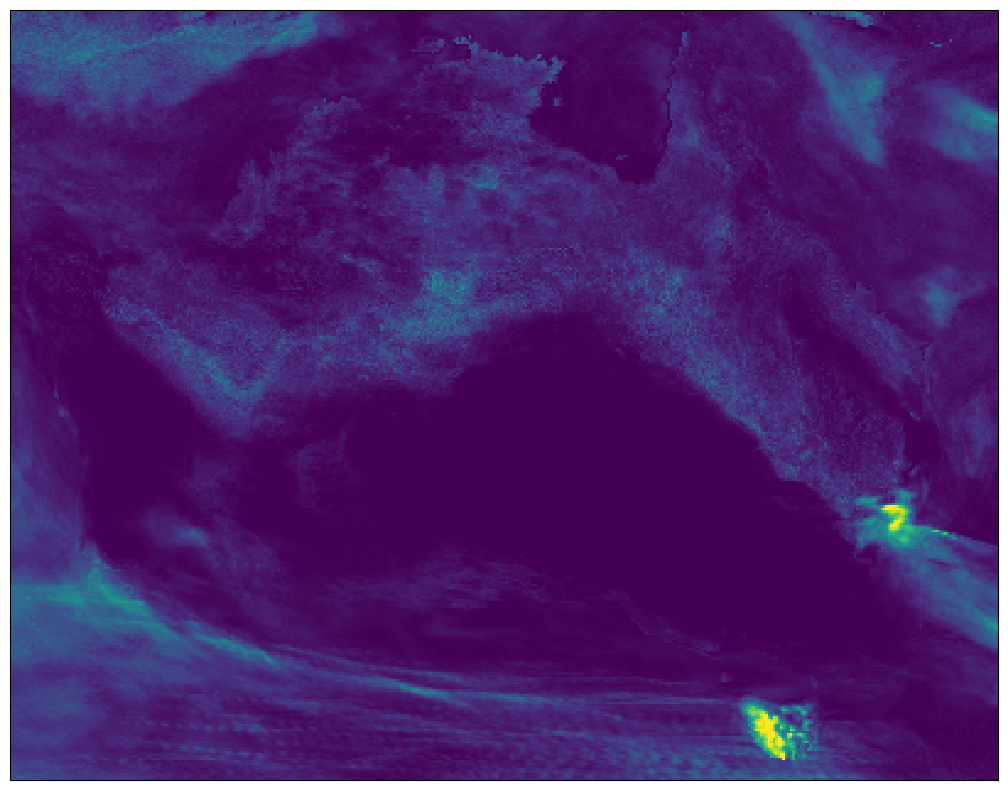

In [35]:
fig, ax = plt.subplots(figsize=(16,10), subplot_kw={'projection': ccrs.PlateCarree()})

mesh = ax.pcolormesh(
    bar.lon,
    bar.lat,
    bar.clwvi.mean(dim='time'),
    cmap='viridis', shading='auto',
    vmin=0, vmax=0.2,
    transform=ccrs.PlateCarree()
)

In [50]:
ds_reg = ds_reg.interp(
    lat=bar.lat,
    lon=bar.lon,
    method='linear'
)

In [ ]:
# bar = get_barra()
# him = get_himawari(2020)

# # time slice based on himawari
# start = him.isel(time=0).time
# end = him.isel(time=-1).time
# bar = bar.sel(time=him.time)

# # Regrid Himawari to BARRA
# him = him.interp(
#     lat=bar.lat,
#     lon=bar.lon,
#     method='linear'
# )

In [52]:
from scores.spatial import fss_2d

In [61]:
obs = ds_reg.cmic_lwp
fcst = bar.clwvi

def drop_duplicate_times(da):
    _, index = np.unique(da['time'], return_index=True)
    return da.isel(time=index)

obs = drop_duplicate_times(obs)
fcst = drop_duplicate_times(fcst)

obs, fcst = xr.align(obs, fcst)

obs = obs.compute()
fcst = fcst.compute()

2025-10-22 20:28:33,091:py.warnings:WARNING: /g/data/xp65/public/apps/med_conda/envs/analysis3-25.06/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 20.02 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(

2025-10-22 20:28:33,091:py.warnings:WARNING: /g/data/xp65/public/apps/med_conda/envs/analysis3-25.06/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 20.02 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(

This may

In [62]:
obs.dims == fcst.dims

True

In [63]:
obs.shape == fcst.shape

True

In [ ]:
obs = obs.mean(dim='time')
fcst = fcst.mean(dim='time')

In [85]:
f = xr.where(obs > 0, 1, 0).sum().item() / obs.size
L = 0.5 + f/2

In [86]:
L

0.8097193026821135

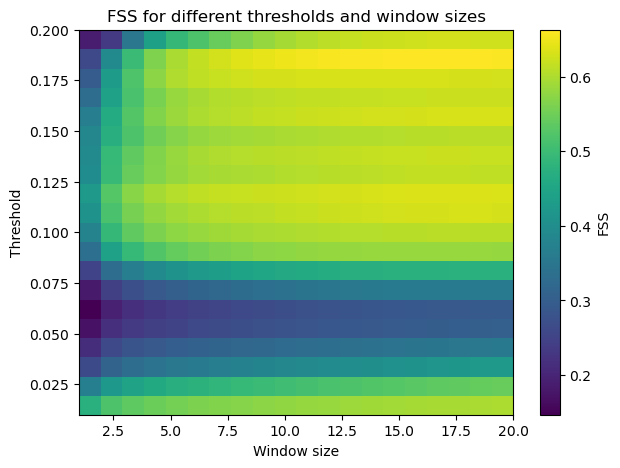

In [87]:
thresholds = np.linspace(0.01, 0.2, 20)
window_sizes = np.arange(1, 21)  # 1..10

# Empty array to store results
fss_results = np.zeros((len(thresholds), len(window_sizes)))

for i, thr in enumerate(thresholds):
    for j, win in enumerate(window_sizes):
        fss = fss_2d(
            fcst,
            obs,
            event_threshold=thr,
            window_size=(win, win),
            spatial_dims=["lat", "lon"],
        )
        # Extract a scalar if needed
        if isinstance(fss, xr.DataArray):
            fss = fss.item()
        fss_results[i, j] = fss

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(
    fss_results,
    origin="lower",
    aspect="auto",
    extent=[window_sizes[0], window_sizes[-1], thresholds[0], thresholds[-1]],
    cmap="viridis"
)
cbar = plt.colorbar(im, ax=ax, label="FSS")

ax.set_xlabel("Window size")
ax.set_ylabel("Threshold")
ax.set_title("FSS for different thresholds and window sizes")

plt.show()
